# Project 1 — KNN
## Gemstone Type Classification

Classifying gemstones into 3 types (Type A, B, C) based on physical properties: hardness, refractive index, density, and carat weight. Synthetic dataset, generated in-notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 600
gem_type = np.random.choice(['TypeA','TypeB','TypeC'], n, p=[0.4,0.35,0.25])
base = {'TypeA': (7.5, 1.55, 3.2), 'TypeB': (5.5, 1.7, 2.6), 'TypeC': (9.0, 2.4, 3.9)}
hardness, refractive_index, density = [], [], []
for g in gem_type:
    h, r, d = base[g]
    hardness.append(np.random.normal(h, 0.4))
    refractive_index.append(np.random.normal(r, 0.08))
    density.append(np.random.normal(d, 0.2))
carat = np.random.gamma(2, 0.8, n)

df = pd.DataFrame({'hardness': hardness, 'refractive_index': refractive_index,
                    'density': density, 'carat': carat, 'gem_type': gem_type})
df.head()


,hardness,refractive_index,density,carat,gem_type
0,7.287897,1.486570,3.178594,0.413047,TypeA
1,8.585903,2.355708,3.660424,1.745255,TypeC
2,6.285890,1.702821,2.460055,1.549542,TypeB
3,5.585592,1.691014,2.555806,3.060200,TypeB
4,7.745667,1.610601,3.093900,0.504863,TypeA


## 2. Preprocessing

In [3]:
le = LabelEncoder()
X = df.drop('gem_type', axis=1)
y = le.fit_transform(df['gem_type'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Train Model

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# quick check for best k
for k in [3,5,7,9,11]:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train, cv=5)
    print(f"k={k}: CV accuracy={scores.mean():.3f}")

model = KNeighborsClassifier(n_neighbors=5, weights='distance')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


k=3: CV accuracy=0.996
k=5: CV accuracy=0.994
k=7: CV accuracy=0.998
k=9: CV accuracy=0.998
k=11: CV accuracy=0.998


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00        32

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



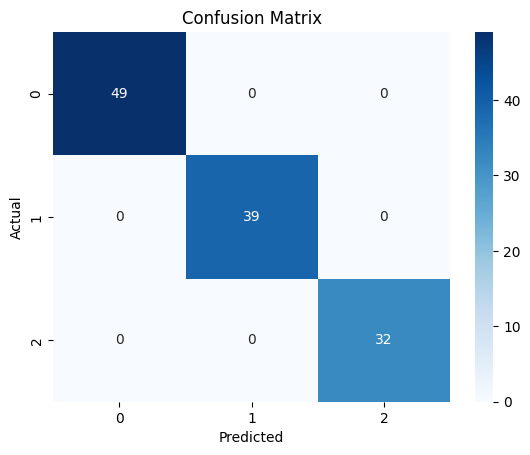

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- KNN has no coefficients to interpret — it's purely distance-based, so there's no "feature importance" in the traditional sense.
- Try plotting decision boundaries for 2 features at a time to visualize how KNN partitions space.
- Next steps: try `weights='uniform'` vs `'distance'`, and test sensitivity to outliers by injecting a few extreme points.

---
